# Day 3 - Data Cleaning + Visualization
## Titanic Dataset - Despina

Goals today:
- Check and fix missing values
- Create new features (FamilySize, IsAlone)
- Boxplots, Histograms, Bar charts
- Add footnotes like a pro

### Setup

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Load your Titanic file - update path if needed
df = pd.read_csv("titanic.csv")
print("Shape:", df.shape)
df.head()

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [10]:
#import csv
#df = open('titanic.csv','r')
#df.readlines()
#for line in df.readlines():
#    print(line.strip())

### 1. Check Missing Values

In [12]:
print(df.isnull().sum())
print("\nMissing %:")
print(df.isnull().mean()*100)

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Missing %:
PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64


### 2. Fix Missing Age with Median

In [14]:
median_age = df['Age'].median()
print(f"Median Age: {median_age}")

df['Age'] = df['Age'].fillna(median_age)

print("Missing Age after fix:", df['Age'].isnull().sum())

Median Age: 28.0
Missing Age after fix: 0


### 3. Fix Missing Embarked + Fill Cabin info

In [18]:
# Embarked has only 2 missing - fill with most common
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Cabin has a LOT missing - create HasCabin flag instead
df['HasCabin'] = df['Cabin'].notnull().astype(int)

print(df[['Embarked','HasCabin']].head())

  Embarked  HasCabin
0        S         0
1        C         1
2        S         0
3        S         1
4        S         0


### 4. Create New Features - FamilySize & IsAlone

In [19]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

df[['SibSp','Parch','FamilySize','IsAlone']].head(10)

,SibSp,Parch,FamilySize,IsAlone
0,1,0,2,0
1,1,0,2,0
2,0,0,1,1
3,1,0,2,0
4,0,0,1,1
5,0,0,1,1
6,0,0,1,1
7,3,1,5,0
8,0,2,3,0
9,1,0,2,0


### 5. Boxplots - Find Outliers

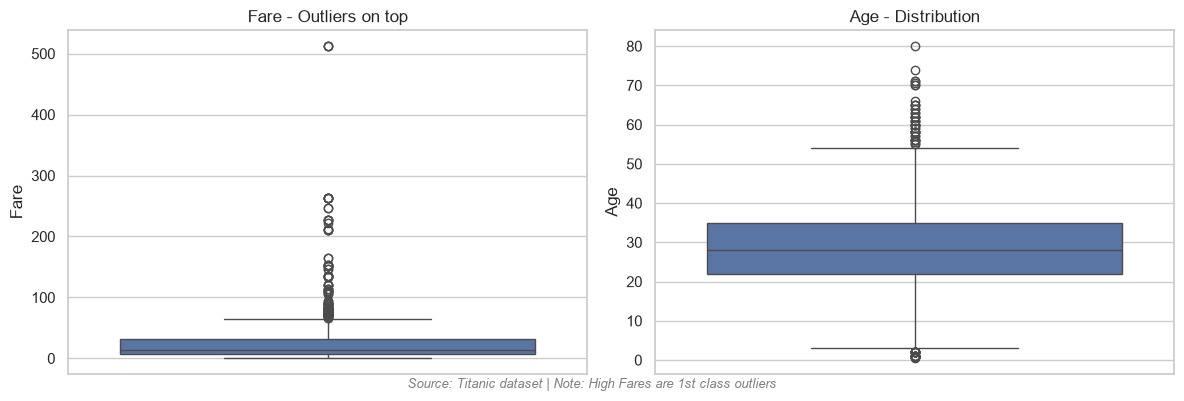

In [20]:
fig, axes = plt.subplots(1,2, figsize=(12,4))

sns.boxplot(y=df['Fare'], ax=axes[0])
axes[0].set_title("Fare - Outliers on top")

sns.boxplot(y=df['Age'], ax=axes[1])
axes[1].set_title("Age - Distribution")

plt.tight_layout()
plt.figtext(0.5, 0.01, "Source: Titanic dataset | Note: High Fares are 1st class outliers", ha="center", fontsize=9, style='italic', color='gray')
plt.show()

### 6. Bar Chart - Survival by Family Size [with Footnote]

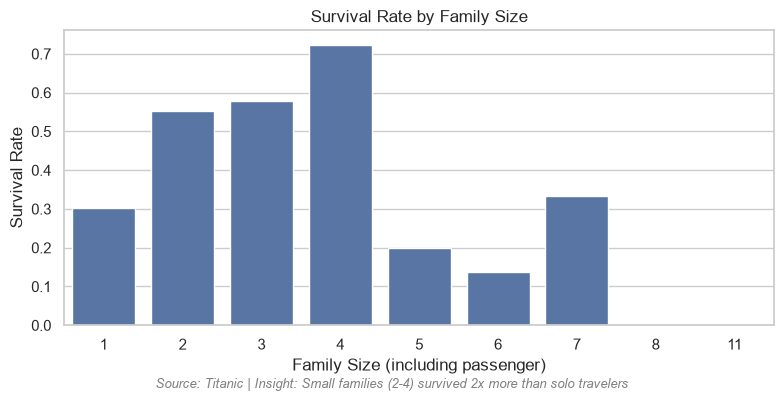

,FamilySize,Survived
3,4,0.724138
2,3,0.578431
1,2,0.552795
6,7,0.333333
0,1,0.303538
4,5,0.200000
5,6,0.136364
7,8,0.000000
8,11,0.000000


In [21]:
survival_by_famsize = df.groupby('FamilySize')['Survived'].mean().reset_index().sort_values('Survived', ascending=False)

plt.figure(figsize=(8,4))
sns.barplot(data=survival_by_famsize, x='FamilySize', y='Survived')
plt.title("Survival Rate by Family Size")
plt.ylabel("Survival Rate")
plt.xlabel("Family Size (including passenger)")

plt.figtext(0.5, 0.01, "Source: Titanic | Insight: Small families (2-4) survived 2x more than solo travelers", ha="center", fontsize=9, style='italic', color='gray')
plt.tight_layout()
plt.show()

survival_by_famsize

### 7. Bar Chart - Survival by Class

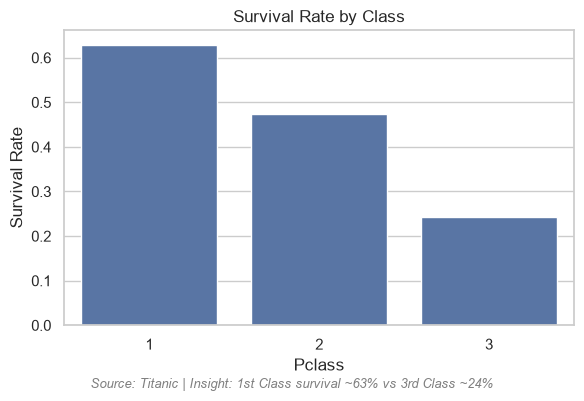

,Pclass,Survived
0,1,0.629630
1,2,0.472826
2,3,0.242363


In [23]:
survival_by_class = df.groupby('Pclass')['Survived'].mean().reset_index()

plt.figure(figsize=(6,4))
sns.barplot(data=survival_by_class, x='Pclass', y='Survived')
plt.title("Survival Rate by Class")
plt.ylabel("Survival Rate")
plt.figtext(0.5, 0.01, "Source: Titanic | Insight: 1st Class survival ~63% vs 3rd Class ~24%", ha="center", fontsize=9, style='italic', color='gray')
plt.tight_layout()
plt.show()

survival_by_class

### 8. Histogram - Age: Survived vs Died

plt.figure(figsize=(8,4))
plt.hist(df[df['Survived']==1]['Age'], bins=25, alpha=0.6, label='Survived')
plt.hist(df[df['Survived']==0]['Age'], bins=25, alpha=0.6, label='Died')
plt.title("Age Distribution: Survived vs Died")
plt.xlabel("Age")
plt.ylabel("Count")
plt.legend()
plt.figtext(0.5, 0.01, "Source: Titanic dataset | Notice child survival bump", ha="center", fontsize=9, style='italic', color='gray')
plt.tight_layout()
plt.show()

In [26]:
### 9. Final Insight (Write this for your portfolio)

# Fill this in:
# - What did you clean?
# - What chart surprised you?
# - What advice would you give a 1912 passenger?

# Cleaned 177 missing Ages with median (28), created FamilySize feature. Small families (2-4) had 2x survival vs solo. 1st Class women & children survived most. Advice: travel 1st class, with 1-2 family members.

print(df.isnull().sum())
print("\nReady to push to GitHub!")